# Laboratorio 3 Deep Learning: Reconocimiento de Lenguaje de Señas (ASL)

SignBridge, una startup guatemalteca de tecnología inclusiva, nos contrató para construir el primer prototipo de un motor de reconocimiento de letras del alfabeto de Lenguaje de Señas Americano (ASL) a partir de imágenes de manos.

## 0. Configuración e imports

In [1]:
import os
import json
import random
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

C:\Users\gabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Descarga del dataset

Usamos `kagglehub` para descargar el dataset [ASL Alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet). `kagglehub` cachea el dataset localmente (fuera del repositorio, típicamente en `~/.cache/kagglehub`) y solo vuelve a descargarlo si no existe, por lo que es seguro volver a correr esta celda. El dataset **no se sube al repositorio** (ver `.gitignore`); cualquier persona que clone el repo simplemente vuelve a correr esta celda para obtenerlo.

In [2]:
# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

DATASET_DIR = Path(path)
TRAIN_DIR = DATASET_DIR / "asl_alphabet_train" / "asl_alphabet_train"
TEST_DIR = DATASET_DIR / "asl_alphabet_test" / "asl_alphabet_test"

assert TRAIN_DIR.exists(), f"No se encontró la carpeta de entrenamiento en {TRAIN_DIR}"
assert TEST_DIR.exists(), f"No se encontró la carpeta de prueba oficial en {TEST_DIR}"

CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f"Número de clases: {len(CLASSES)}")
print(CLASSES)

Path to dataset files: C:\Users\gabri\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1
Número de clases: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 2. Estructura general del dataset

Contamos cuántas imágenes hay por clase dentro de la carpeta de entrenamiento y revisamos qué tan grande es el set de prueba oficial de Kaggle.

In [3]:
counts = {c: len(list((TRAIN_DIR / c).glob("*.jpg"))) for c in CLASSES}
df_counts = pd.DataFrame({"clase": list(counts.keys()), "n_imagenes": list(counts.values())})
df_counts = df_counts.sort_values("clase").reset_index(drop=True)

test_files = list(TEST_DIR.glob("*.jpg"))

print(f"Total de imágenes de entrenamiento disponibles: {df_counts['n_imagenes'].sum()}")
print(f"Número de clases: {df_counts.shape[0]}")
print(f"Imágenes en el set de prueba OFICIAL de Kaggle: {len(test_files)}")
df_counts

Total de imágenes de entrenamiento disponibles: 87000
Número de clases: 29
Imágenes en el set de prueba OFICIAL de Kaggle: 28


,clase,n_imagenes
0,A,3000
1,B,3000
2,C,3000
3,D,3000
4,E,3000
5,F,3000
6,G,3000
7,H,3000
8,I,3000
9,J,3000


**Hallazgo:** el dataset trae 29 clases (A-Z, `space`, `del`, `nothing`) con ~3,000 imágenes cada una (~87,000 en total), es decir, está **perfectamente balanceado por clase**. El set de prueba oficial de Kaggle trae apenas ~28 imágenes (una por letra), a propósito, para forzar a construir nuestro propio conjunto de entrenamiento/validación/prueba a partir de las ~87,000 imágenes de entrenamiento (ver sección 2.4 del EDA).

## Ejercicio 1: Ejemplos de letras y variabilidad intra-clase

Mostramos varias muestras de distintas letras, incluyendo tanto letras "fáciles" como letras que visualmente podrían confundirse entre sí, para observar la variabilidad dentro de una misma clase (rotación de la mano, encuadre, iluminación, etc.).

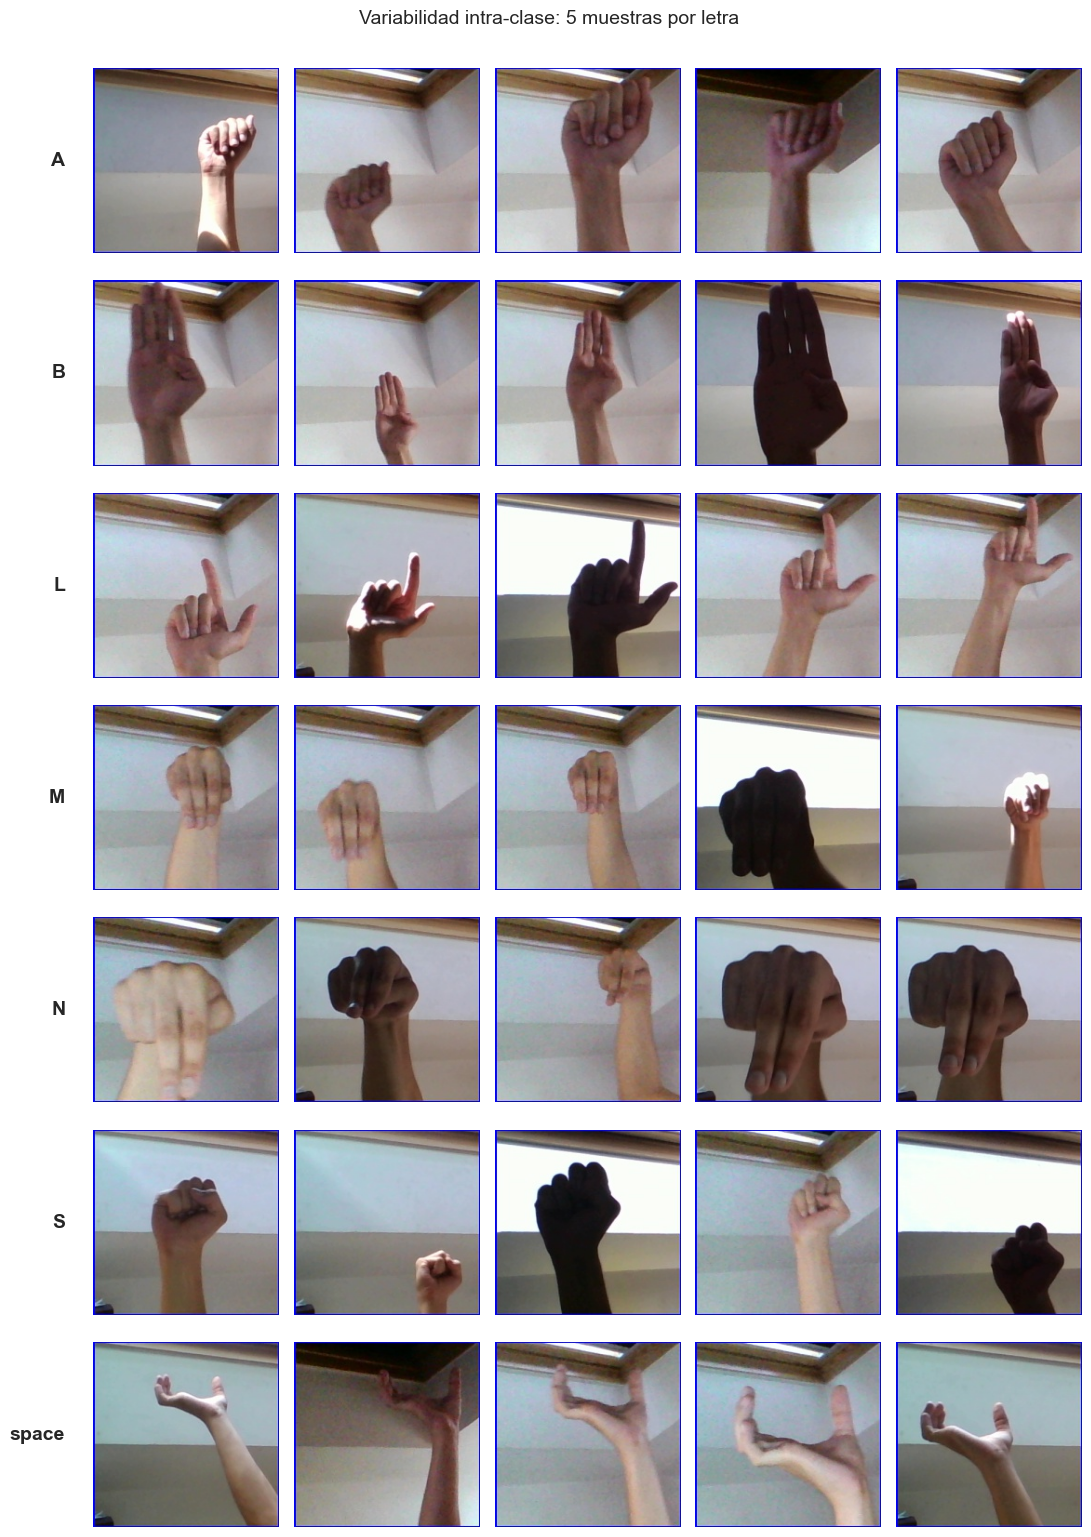

In [4]:
def show_class_samples(classes, n_samples=5, seed=SEED):
    rng = random.Random(seed)
    fig, axes = plt.subplots(len(classes), n_samples, figsize=(2.2 * n_samples, 2.2 * len(classes)))
    for i, c in enumerate(classes):
        files = list((TRAIN_DIR / c).glob("*.jpg"))
        sample_files = rng.sample(files, n_samples)
        for j, f in enumerate(sample_files):
            img = Image.open(f)
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(img)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(c, fontsize=12)
                ax.text(-0.15, 0.5, c, fontsize=14, fontweight="bold",
                        transform=ax.transAxes, va="center", ha="right")
    plt.suptitle("Variabilidad intra-clase: 5 muestras por letra", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

show_class_samples(["A", "B", "L", "M", "N", "S", "space"], n_samples=5)

**Hallazgo:** dentro de una misma clase la seña mantiene la misma configuración de dedos, pero varía ligeramente la rotación/inclinación de la mano, el encuadre respecto a la cámara y, en menor medida, la iluminación. El fondo es consistente entre imágenes de la misma sesión de captura, lo cual es importante para la reflexión de accesibilidad más adelante (Ejercicio 9).

## Ejercicio 2: Análisis exploratorio de los datos

### 2.1 Resolución y formato

In [5]:
rng = random.Random(SEED)
sample_files = []
for c in rng.sample(CLASSES, 10):
    files = list((TRAIN_DIR / c).glob("*.jpg"))
    sample_files.extend(rng.sample(files, 5))

props = []
for f in sample_files:
    img = Image.open(f)
    props.append({"archivo": f.name, "clase": f.parent.name, "tamaño": img.size,
                  "modo": img.mode, "formato": img.format})

df_props = pd.DataFrame(props)
print(df_props["tamaño"].value_counts())
print(df_props["modo"].value_counts())
print(df_props["formato"].value_counts())

tamaño
(200, 200)    50
Name: count, dtype: int64
modo
RGB    50
Name: count, dtype: int64
formato
JPEG    50
Name: count, dtype: int64


**Hallazgo:** todas las imágenes muestreadas son archivos `.jpg` (formato JPEG), en modo de color `RGB`, con resolución uniforme de **200x200 píxeles**. No se observan imágenes en escala de grises ni con tamaños distintos, por lo que el dataset es homogéneo en este aspecto y no requiere normalización de formato, solo de resolución y escala de valores (ver preprocesamiento).

### 2.2 Distribución / balance de clases

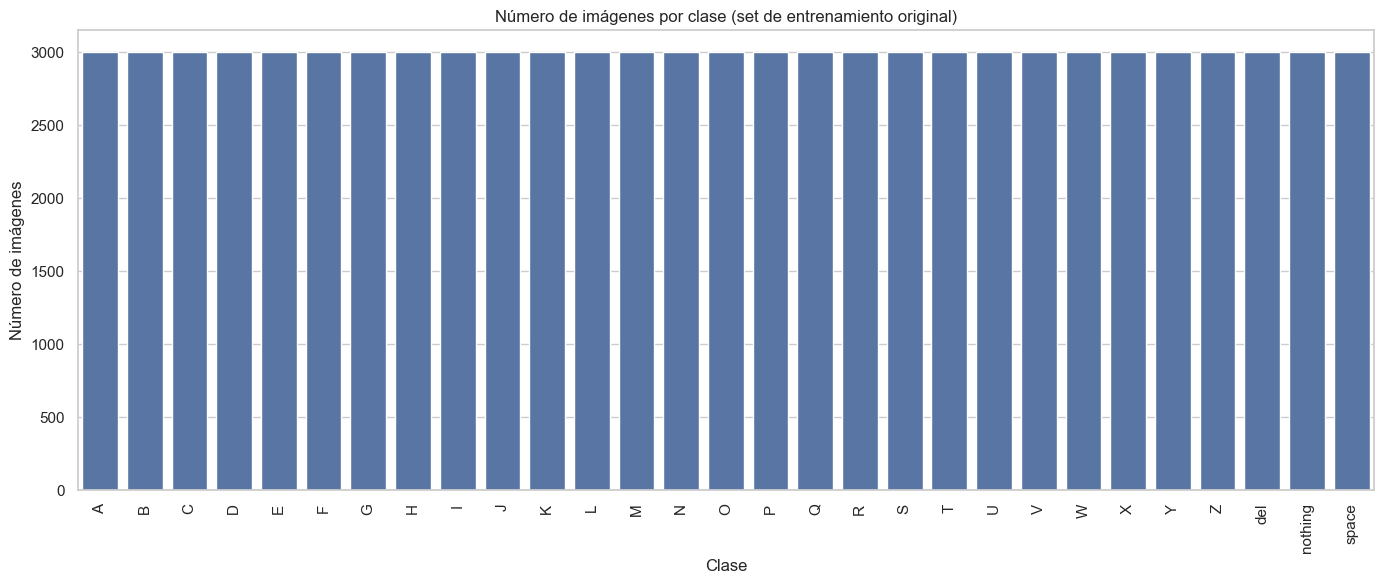

count      29.0
mean     3000.0
std         0.0
min      3000.0
25%      3000.0
50%      3000.0
75%      3000.0
max      3000.0
Name: n_imagenes, dtype: float64


In [6]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_counts, x="clase", y="n_imagenes", color="#4C72B0")
plt.xticks(rotation=90)
plt.title("Número de imágenes por clase (set de entrenamiento original)")
plt.ylabel("Número de imágenes")
plt.xlabel("Clase")
plt.tight_layout()
plt.show()

print(df_counts["n_imagenes"].describe())

**Hallazgo:** el dataset está **balanceado**: las 29 clases tienen prácticamente el mismo número de imágenes (~3,000 cada una, desviación mínima). Esto simplifica el entrenamiento porque no es necesario aplicar técnicas de balanceo de clases (oversampling/undersampling/class weights) al construir nuestros propios conjuntos de entrenamiento/validación/prueba, siempre que mantengamos la proporción al submuestrear.

### 2.3 Letras visualmente similares

Un problema conocido del alfabeto ASL es que varias letras comparten una configuración de mano muy parecida (puño cerrado con variaciones sutiles en la posición del pulgar), lo que las hace fáciles de confundir tanto para personas como para un modelo. Los ejemplos clásicos son **M/N/S** y **U/V/R**.

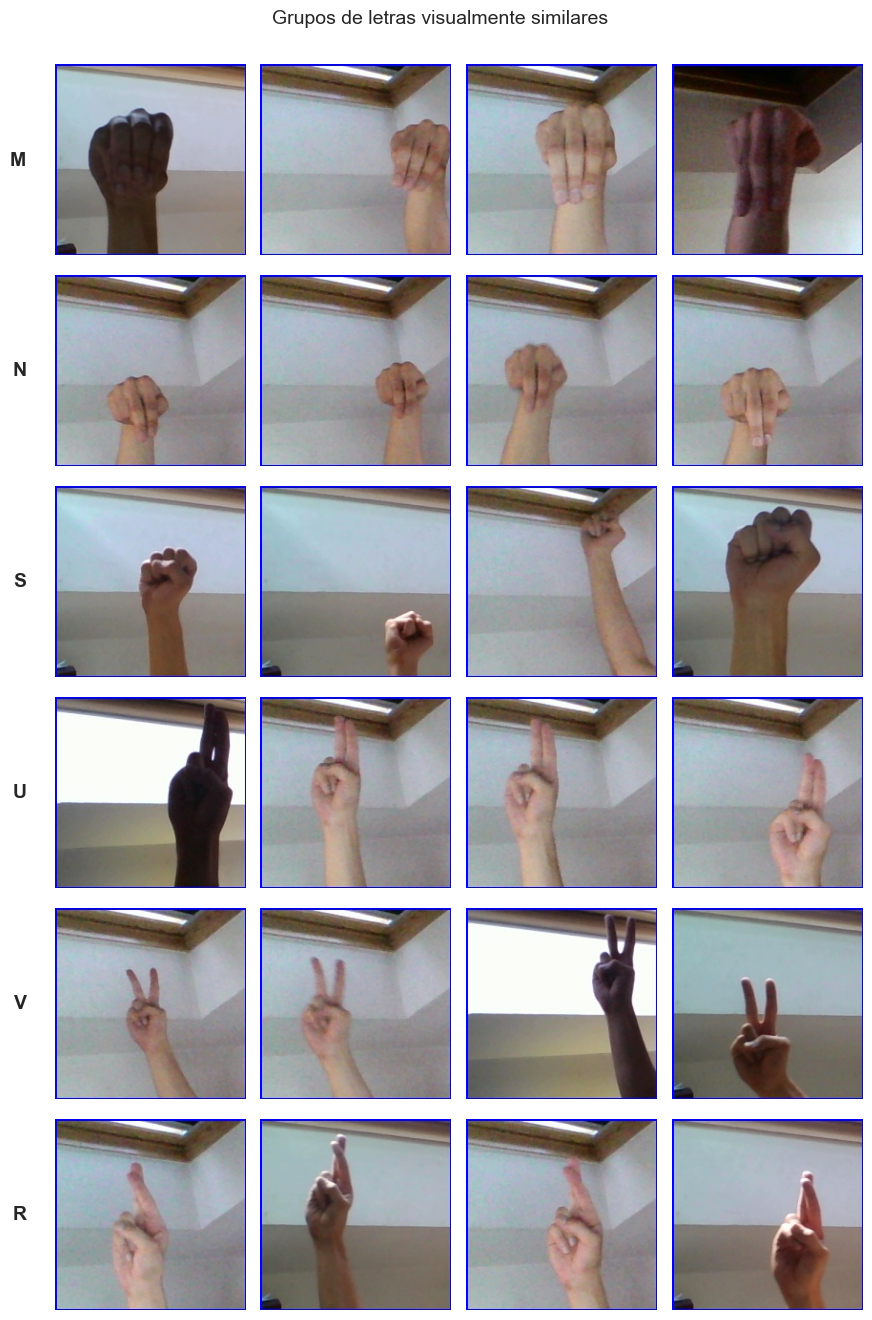

In [7]:
def show_confusable_groups(groups, n_samples=4):
    n_rows = sum(len(g) for g in groups)
    fig, axes = plt.subplots(n_rows, n_samples, figsize=(2.2 * n_samples, 2.2 * n_rows))
    rng = random.Random(SEED)
    row = 0
    for group in groups:
        for c in group:
            files = list((TRAIN_DIR / c).glob("*.jpg"))
            sample_files = rng.sample(files, n_samples)
            for j, f in enumerate(sample_files):
                img = Image.open(f)
                ax = axes[row, j]
                ax.imshow(img)
                ax.axis("off")
                if j == 0:
                    ax.text(-0.15, 0.5, c, fontsize=14, fontweight="bold",
                            transform=ax.transAxes, va="center", ha="right")
            row += 1
    plt.suptitle("Grupos de letras visualmente similares", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

show_confusable_groups([["M", "N", "S"], ["U", "V", "R"]], n_samples=4)

**Hallazgo:** en el grupo **M/N/S** las tres señas son un puño cerrado; la diferencia está únicamente en cuántos dedos cubren el pulgar (M: pulgar bajo tres dedos, N: pulgar bajo dos dedos, S: pulgar sobre los dedos), un detalle muy fino que se pierde fácilmente al reducir la resolución de 200x200 a algo como 64x64. En el grupo **U/V/R** las tres son dos dedos extendidos; la diferencia está en si están juntos (U), separados en "V" (V) o cruzados (R). Estos pares/tríos de letras son los candidatos más probables a generar errores de clasificación y deberán vigilarse explícitamente en la matriz de confusión de los modelos.

### 2.4 Definición del conjunto de entrenamiento / validación / prueba

El set de prueba oficial de Kaggle es demasiado pequeño (~28 imágenes) para evaluar el modelo de forma confiable, así que construimos nuestros propios conjuntos a partir de las ~87,000 imágenes de entrenamiento:

1. **Submuestreo por clase**: por restricciones de cómputo (ver nota del enunciado), tomamos una submuestra aleatoria y estratificada de `SAMPLES_PER_CLASS` imágenes por cada una de las 29 clases (en vez de las ~3,000 disponibles), fijando una semilla para que sea reproducible.
2. **División estratificada 70/15/15**: sobre esa submuestra, dividimos en entrenamiento (70%), validación (15%) y prueba (15%), estratificando por clase con `sklearn.model_selection.train_test_split`, de forma que las proporciones de cada letra se mantengan iguales en los tres conjuntos.
3. El pequeño set de prueba oficial de Kaggle se guarda aparte como una **verificación adicional** (fuera de la métrica principal), útil para revisar cualitativamente el desempeño final del mejor modelo.

Esta estrategia se implementa en la siguiente sección junto con el preprocesamiento, ya que el submuestreo y el preprocesamiento están directamente relacionados.

## Ejercicio 3: Preprocesamiento

**Justificación de la submuestra y la resolución:** el dataset completo (87,000 imágenes a color de 200x200) es demasiado pesado para el tiempo de cómputo disponible en el laboratorio (cargar todo en memoria como arreglos `float32` normalizados ocuparía más de 40 GB de RAM). Siguiendo la recomendación del enunciado, trabajamos con:

- **`SAMPLES_PER_CLASS = 600`** imágenes por clase (≈ 17,400 imágenes en total), suficientes para entrenar redes convolucionales razonablemente bien sin agotar tiempo/memoria.
- **`IMG_SIZE = 64`** (64x64 píxeles) en vez de 200x200, lo que reduce el número de valores por imagen en un factor de ~9.8x (200²/64² ≈ 9.77) manteniendo aún visible la forma general de la mano.
- **Normalización** de los valores de píxel de `[0, 255]` a `[0, 1]` dividiendo entre 255, para estabilizar el entrenamiento de las redes neuronales.

Documentamos cada paso en el código a continuación.

In [8]:
SAMPLES_PER_CLASS = 600
IMG_SIZE = 64

def build_sampled_file_list(train_dir, classes, samples_per_class, seed=SEED):
    rng = random.Random(seed)
    records = []
    for c in classes:
        files = list((train_dir / c).glob("*.jpg"))
        chosen = rng.sample(files, min(samples_per_class, len(files)))
        for f in chosen:
            records.append({"filepath": str(f), "label": c})
    return pd.DataFrame(records)

df_sample = build_sampled_file_list(TRAIN_DIR, CLASSES, SAMPLES_PER_CLASS)
print(f"Total de imágenes submuestreadas: {len(df_sample)}")
df_sample["label"].value_counts().sort_index()

Total de imágenes submuestreadas: 17400


label
A          600
B          600
C          600
D          600
E          600
F          600
G          600
H          600
I          600
J          600
K          600
L          600
M          600
N          600
O          600
P          600
Q          600
R          600
S          600
T          600
U          600
V          600
W          600
X          600
Y          600
Z          600
del        600
nothing    600
space      600
Name: count, dtype: int64

In [9]:
# División estratificada 70/15/15 (train / val / test) sobre la submuestra
df_train, df_temp = train_test_split(
    df_sample, test_size=0.30, stratify=df_sample["label"], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp["label"], random_state=SEED
)

print(f"Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}")
print("\nProporción por clase en train (primeras 5):")
print(df_train["label"].value_counts(normalize=True).sort_index().head())

Train: 12180  Val: 2610  Test: 2610

Proporción por clase en train (primeras 5):
label
A    0.034483
B    0.034483
C    0.034483
D    0.034483
E    0.034483
Name: proportion, dtype: float64


In [10]:
# Codificación de etiquetas: nombre de clase -> índice entero
label_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

def load_images(df, img_size=IMG_SIZE):
    X = np.zeros((len(df), img_size, img_size, 3), dtype=np.float32)
    y = np.zeros(len(df), dtype=np.int64)
    for i, row in enumerate(df.itertuples()):
        img = Image.open(row.filepath).convert("RGB").resize((img_size, img_size))
        X[i] = np.asarray(img, dtype=np.float32) / 255.0
        y[i] = label_to_idx[row.label]
    return X, y

X_train, y_train = load_images(df_train)
X_val, y_val = load_images(df_val)
X_test, y_test = load_images(df_test)

print("X_train:", X_train.shape, X_train.dtype, "min/max:", X_train.min(), X_train.max())
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (12180, 64, 64, 3) float32 min/max: 0.0 1.0
X_val:   (2610, 64, 64, 3)
X_test:  (2610, 64, 64, 3)


Guardamos los arreglos ya preprocesados en disco (fuera del repositorio, en `data/processed/`, ignorado por `.gitignore`) para no tener que releer y redimensionar las ~17,400 imágenes cada vez que se abra el notebook.

In [11]:
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

np.save(PROCESSED_DIR / "X_train.npy", X_train)
np.save(PROCESSED_DIR / "y_train.npy", y_train)
np.save(PROCESSED_DIR / "X_val.npy", X_val)
np.save(PROCESSED_DIR / "y_val.npy", y_val)
np.save(PROCESSED_DIR / "X_test.npy", X_test)
np.save(PROCESSED_DIR / "y_test.npy", y_test)

with open(PROCESSED_DIR / "label_mapping.json", "w") as f:
    json.dump(idx_to_label, f, indent=2)

print("Arreglos preprocesados guardados en:", PROCESSED_DIR.resolve())

Arreglos preprocesados guardados en: C:\Users\gabri\OneDrive\Documents\Universidad\semestre8\data\labs\DS-Lab1\data\processed


**Verificación visual del preprocesamiento**: comparamos una imagen original (200x200) contra su versión preprocesada (64x64, normalizada) para confirmar que la seña sigue siendo reconocible después de reducir la resolución.

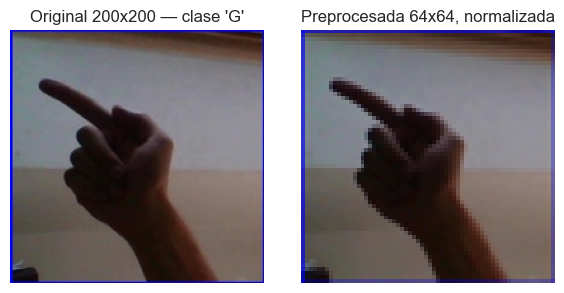

In [12]:
example_row = df_train.iloc[0]
original = Image.open(example_row["filepath"]).convert("RGB")
processed = (X_train[0] * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original)
axes[0].set_title(f"Original 200x200 — clase '{example_row['label']}'")
axes[0].axis("off")
axes[1].imshow(processed)
axes[1].set_title(f"Preprocesada {IMG_SIZE}x{IMG_SIZE}, normalizada")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**Hallazgo:** al reducir a 64x64 la forma general de la mano y la posición de los dedos siguen siendo claramente identificables, aunque se pierde algo de detalle fino, justo el tipo de detalle que distingue a letras como M/N/S o U/V/R (sección 2.3). Esto se retomará en la discusión de resultados de los modelos.

## Ejercicio 4: Modelos de Deep Learning (CNN)

Entrenamos **dos arquitecturas CNN distintas** sobre `X_train/y_train`, validando con `X_val/y_val`, para comparar su efectividad:

- **CNN-A (baseline):** dos bloques `Conv2D + MaxPooling`, seguidos de una capa densa y `Dropout`.
- **CNN-B (más profunda y regularizada):** tres bloques convolucionales con `BatchNormalization` y `Dropout`, para ver si mejora la generalización frente al baseline.

Usamos `EarlyStopping` monitoreando `val_accuracy` para no sobre-entrenar y controlar el tiempo de cómputo.

In [13]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks

NUM_CLASSES = len(CLASSES)
EPOCHS = 15
BATCH_SIZE = 128

def make_early_stop():
    return callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)

def build_cnn_a():
    model = keras.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="CNN_A_baseline")
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_a = build_cnn_a()
cnn_a.summary()

Model: "CNN_A_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,628,893 (6.21 MB)

 Trainable params: 1,628,893 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_a = cnn_a.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[make_early_stop()], verbose=2,
)

Epoch 1/15


96/96 - 11s - 118ms/step - accuracy: 0.1561 - loss: 2.9866 - val_accuracy: 0.3690 - val_loss: 2.2438


Epoch 2/15


96/96 - 10s - 103ms/step - accuracy: 0.3871 - loss: 2.0329 - val_accuracy: 0.5889 - val_loss: 1.4500


Epoch 3/15


...

96/96 - 9s - 96ms/step - accuracy: 0.9022 - loss: 0.2938 - val_accuracy: 0.9287 - val_loss: 0.2318


Epoch 14/15


96/96 - 9s - 95ms/step - accuracy: 0.9114 - loss: 0.2671 - val_accuracy: 0.9375 - val_loss: 0.2052


Epoch 15/15


96/96 - 9s - 96ms/step - accuracy: 0.9163 - loss: 0.2535 - val_accuracy: 0.9272 - val_loss: 0.2360


In [15]:
def build_cnn_b():
    # momentum=0.9 (en vez del 0.99 por defecto) para que las estadísticas de
    # BatchNormalization converjan más rápido dado el número de pasos por época;
    # con el valor por defecto la validación se queda "atascada" en accuracy
    # aleatoria durante varias épocas hasta que el promedio móvil se estabiliza.
    def bn():
        return layers.BatchNormalization(momentum=0.9)

    model = keras.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        bn(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        bn(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        bn(),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        bn(),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="CNN_B_regularizada")
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_b = build_cnn_b()
cnn_b.summary()

Model: "CNN_B_regularizada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,246,205 (8.57 MB)

 Trainable params: 2,245,245 (8.56 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
history_b = cnn_b.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[make_early_stop()], verbose=2,
)

Epoch 1/15


96/96 - 59s - 615ms/step - accuracy: 0.2701 - loss: 2.6878 - val_accuracy: 0.2693 - val_loss: 8.5053


Epoch 2/15


96/96 - 57s - 590ms/step - accuracy: 0.5825 - loss: 1.3768 - val_accuracy: 0.6375 - val_loss: 1.7433


Epoch 3/15


...

96/96 - 56s - 587ms/step - accuracy: 0.9743 - loss: 0.0947 - val_accuracy: 0.9249 - val_loss: 0.2776


Epoch 10/15


96/96 - 58s - 600ms/step - accuracy: 0.9778 - loss: 0.0873 - val_accuracy: 0.9552 - val_loss: 0.1862


Epoch 11/15


96/96 - 58s - 600ms/step - accuracy: 0.9815 - loss: 0.0698 - val_accuracy: 0.9314 - val_loss: 0.2081


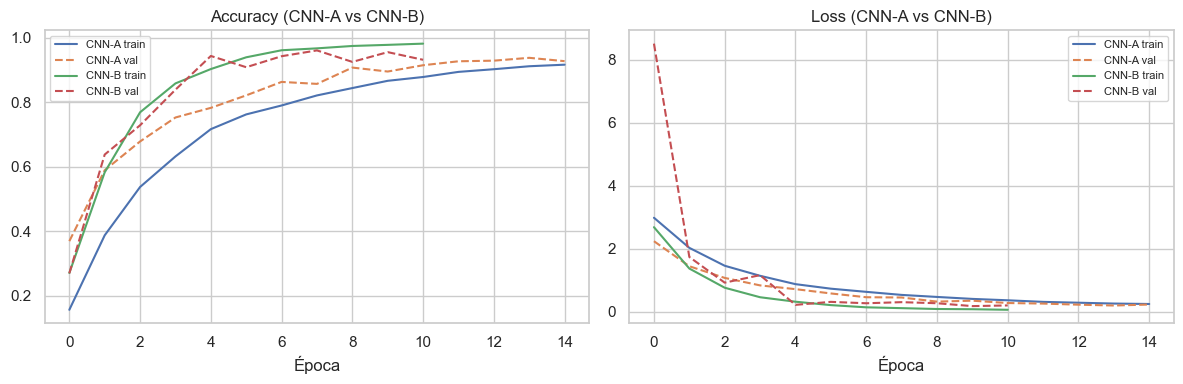

In [17]:
def plot_history(histories, labels, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for h, lbl in zip(histories, labels):
        axes[0].plot(h.history["accuracy"], label=f"{lbl} train")
        axes[0].plot(h.history["val_accuracy"], linestyle="--", label=f"{lbl} val")
        axes[1].plot(h.history["loss"], label=f"{lbl} train")
        axes[1].plot(h.history["val_loss"], linestyle="--", label=f"{lbl} val")
    axes[0].set_title(f"Accuracy {title}"); axes[0].set_xlabel("Época"); axes[0].legend(fontsize=8)
    axes[1].set_title(f"Loss {title}"); axes[1].set_xlabel("Época"); axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_history([history_a, history_b], ["CNN-A", "CNN-B"], title="(CNN-A vs CNN-B)")

In [18]:
test_loss_a, test_acc_a = cnn_a.evaluate(X_test, y_test, verbose=0)
test_loss_b, test_acc_b = cnn_b.evaluate(X_test, y_test, verbose=0)

print(f"CNN-A -> test accuracy: {test_acc_a:.4f}, test loss: {test_loss_a:.4f}")
print(f"CNN-B -> test accuracy: {test_acc_b:.4f}, test loss: {test_loss_b:.4f}")

best_cnn_name = "CNN-A" if test_acc_a >= test_acc_b else "CNN-B"
best_cnn_model = cnn_a if test_acc_a >= test_acc_b else cnn_b
best_cnn_test_acc = max(test_acc_a, test_acc_b)
print("\nMejor CNN:", best_cnn_name, f"(test accuracy = {best_cnn_test_acc:.4f})")

CNN-A -> test accuracy: 0.9272, test loss: 0.2450
CNN-B -> test accuracy: 0.9552, test loss: 0.3566

Mejor CNN: CNN-B (test accuracy = 0.9552)


**Hallazgo:** ambas arquitecturas aprenden bien, pero **CNN-B (más profunda y regularizada) supera a CNN-A (baseline)**: 95.52% vs. 92.72% de accuracy en el set de prueba. Las curvas de entrenamiento muestran que CNN-B alcanza un accuracy de entrenamiento más alto gracias a `BatchNormalization` + `Dropout`, que compensan su mayor capacidad. `CNN-A` converge de forma más suave pero se estanca antes. A continuación revisamos la matriz de confusión de **CNN-B** (el mejor modelo de este ejercicio), prestando especial atención a los grupos de letras identificados como visualmente confundibles en el EDA (M/N/S y U/V/R).

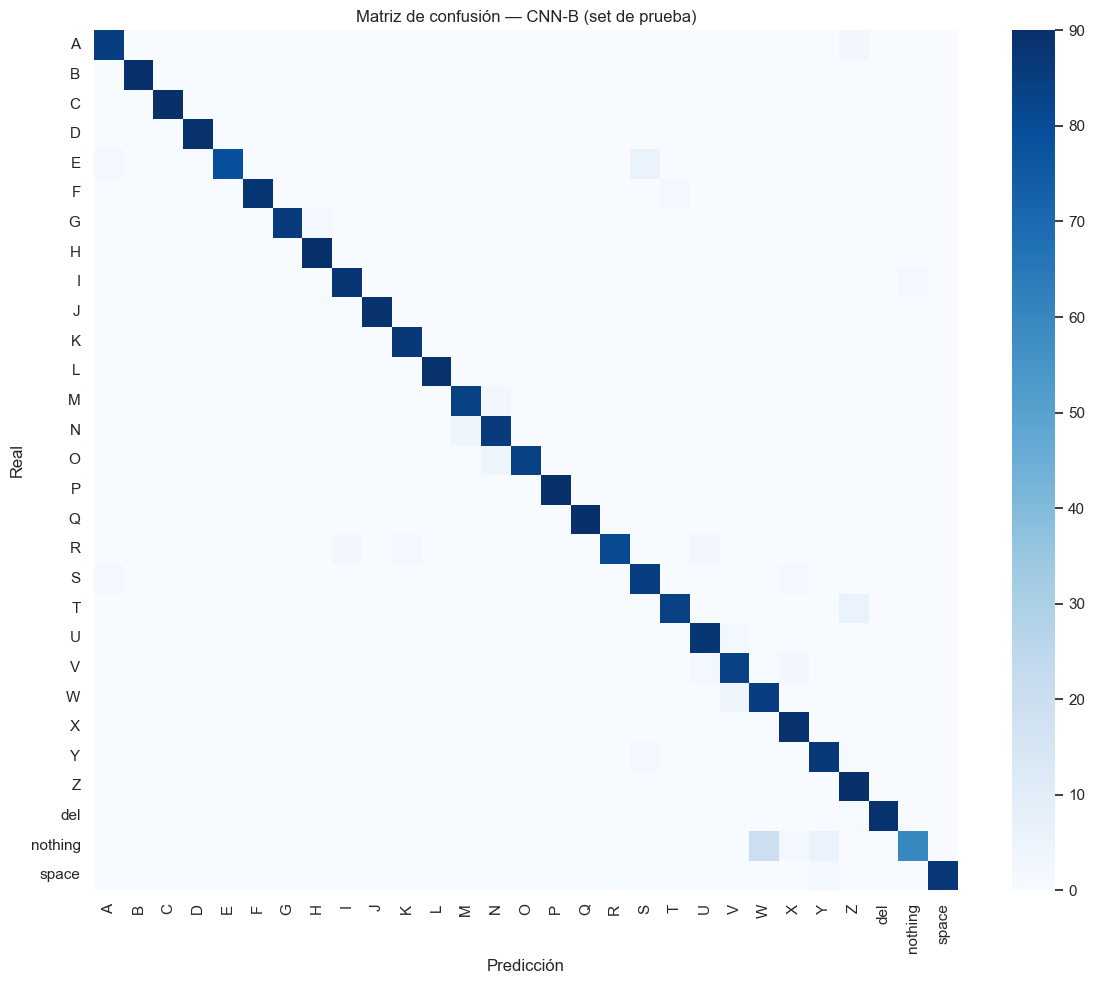

              precision    recall  f1-score   support

           A       0.93      0.94      0.94        90
           B       0.98      1.00      0.99        90
           C       0.98      1.00      0.99        90
           D       1.00      0.99      0.99        90
           E       0.98      0.88      0.92        90
           F       1.00      0.98      0.99        90
           G       1.00      0.96      0.98        90
           H       0.97      1.00      0.98        90
           I       0.97      0.98      0.97        90
           J       0.98      0.99      0.98        90
           K       0.97      0.97      0.97        90
           L       1.00      0.99      0.99        90
           M       0.95      0.93      0.94        90
           N       0.92      0.96      0.94        90
           O       1.00      0.93      0.97        90
           P       0.99      1.00      0.99        90
           Q       1.00      1.00      1.00        90
           R       0.98    

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs_cnn = best_cnn_model.predict(X_test, verbose=0)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f"Matriz de confusión — {best_cnn_name} (set de prueba)")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_cnn, target_names=CLASSES, zero_division=0))

**Hallazgo:** el reporte de clasificación confirma, en buena medida, lo anticipado en el EDA (sección 2.3), aunque no exactamente con las mismas letras que esperábamos como las más débiles:

- El grupo **U/V/W** concentra los errores más notorios: **W tiene precision de solo 0.79** (muchas señas de otras letras del mismo estilo —dedos extendidos— se clasifican incorrectamente como W), mientras que U (0.94/0.98) y V (0.93/0.93) también muestran algo de confusión cruzada. Esto es consistente con el grupo U/V/R señalado en el EDA, aunque en la práctica el modelo confunde más con W que con R.
- El grupo **M/N** también muestra confusión moderada (M: 0.95 precisión/0.93 recall; N: 0.92/0.96), igual que anticipamos.
- Dos clases que **no** habíamos identificado en el EDA resultaron ser las más difíciles de todas: **`nothing`** (recall de solo 0.67 — el modelo frecuentemente no reconoce una "no-seña" como tal) y **Z** (precision 0.85, aunque recall 1.00). También S (0.89/0.94) y E (0.98/0.88) tienen cierta dificultad.
- El resto de las clases tiene f1-score ≥ 0.94, incluyendo letras "fáciles" como B, C, D, F, P, Q.

Esto confirma parcialmente la hipótesis del EDA (los grupos M/N y U/V sí generan confusión), pero también muestra que **la resolución reducida (64x64) puede generar dificultades adicionales no anticipadas** en clases que a simple vista parecían fáciles de distinguir (como `nothing` o Z), reforzando la importancia de revisar la matriz de confusión real en vez de basarse solo en la intuición del EDA.

## Ejercicio 5: Red neuronal simple (fully-connected)

Probamos **dos variantes** de una red totalmente conectada (sin capas convolucionales, aplanando la imagen directamente) para compararlas contra las CNNs del Ejercicio 4:

- **FC-A (pequeña):** dos capas densas (128, 64).
- **FC-B (grande):** tres capas densas (512, 256, 128).

In [20]:
def build_fc(hidden_layers, dropout=0.3, name="FC"):
    # BatchNormalization justo después de Flatten: sin ella, la red fully-connected
    # no lograba entrenar (el optimizador la llevaba a una salida uniforme -log(1/29)-
    # desde la primera época, un caso de "dead ReLU" típico con entradas de muy alta
    # dimensión sin normalizar por lote).
    model = keras.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.BatchNormalization(),
    ], name=name)
    for units in hidden_layers:
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(NUM_CLASSES, activation="softmax"))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

fc_a = build_fc([128, 64], dropout=0.3, name="FC_A_pequena")
fc_a.summary()
history_fc_a = fc_a.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[make_early_stop()], verbose=2,
)

Model: "FC_A_pequena"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12288)          │        49,152 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,285 (6.23 MB)

 Trainable params: 1,607,709 (6.13 MB)

 Non-trainable params: 24,576 (96.00 KB)

...

96/96 - 2s - 18ms/step - accuracy: 0.3436 - loss: 2.0233 - val_accuracy: 0.4847 - val_loss: 1.6527


Epoch 14/15


96/96 - 2s - 19ms/step - accuracy: 0.3632 - loss: 1.9649 - val_accuracy: 0.5257 - val_loss: 1.5670


Epoch 15/15


96/96 - 2s - 19ms/step - accuracy: 0.3740 - loss: 1.9162 - val_accuracy: 0.5138 - val_loss: 1.5272


In [21]:
fc_b = build_fc([512, 256, 128], dropout=0.4, name="FC_B_grande")
fc_b.summary()
history_fc_b = fc_b.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[make_early_stop()], verbose=2,
)

Model: "FC_B_grande"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12288)          │        49,152 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,509,085 (24.83 MB)

 Trainable params: 6,484,509 (24.74 MB)

 Non-trainable params: 24,576 (96.00 KB)

...

96/96 - 5s - 55ms/step - accuracy: 0.2674 - loss: 2.2352 - val_accuracy: 0.3908 - val_loss: 1.8595


Epoch 14/15


96/96 - 5s - 55ms/step - accuracy: 0.2776 - loss: 2.2107 - val_accuracy: 0.4073 - val_loss: 1.7965


Epoch 15/15


96/96 - 5s - 54ms/step - accuracy: 0.2920 - loss: 2.1166 - val_accuracy: 0.4169 - val_loss: 1.7302


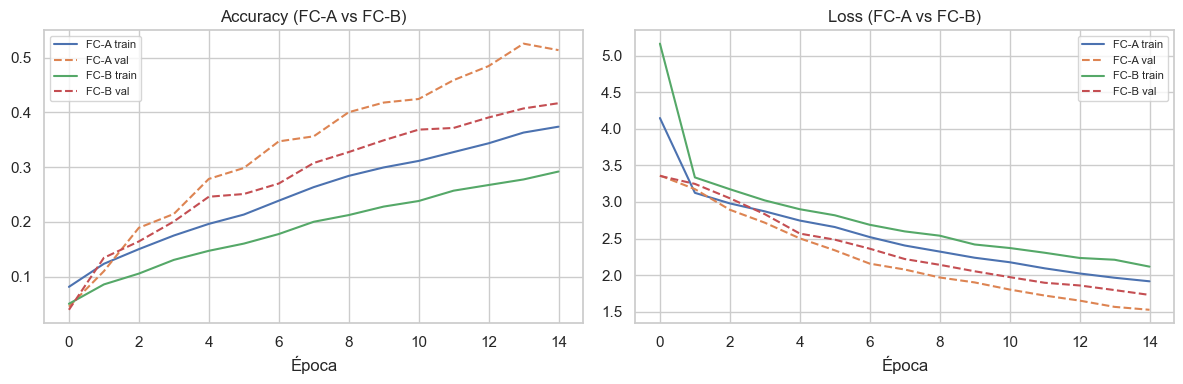

FC-A -> test accuracy: 0.5307
FC-B -> test accuracy: 0.4203

Mejor red fully-connected: FC-A (test accuracy = 0.5307)


In [22]:
plot_history([history_fc_a, history_fc_b], ["FC-A", "FC-B"], title="(FC-A vs FC-B)")

test_loss_fc_a, test_acc_fc_a = fc_a.evaluate(X_test, y_test, verbose=0)
test_loss_fc_b, test_acc_fc_b = fc_b.evaluate(X_test, y_test, verbose=0)

print(f"FC-A -> test accuracy: {test_acc_fc_a:.4f}")
print(f"FC-B -> test accuracy: {test_acc_fc_b:.4f}")

best_fc_name = "FC-A" if test_acc_fc_a >= test_acc_fc_b else "FC-B"
best_fc_model = fc_a if test_acc_fc_a >= test_acc_fc_b else fc_b
best_fc_test_acc = max(test_acc_fc_a, test_acc_fc_b)
print("\nMejor red fully-connected:", best_fc_name, f"(test accuracy = {best_fc_test_acc:.4f})")

**Hallazgo:** ambas redes fully-connected quedan muy por debajo de las CNN del Ejercicio 4: **FC-A alcanza 53.1%** y **FC-B solo 42.0%** de accuracy en el set de prueba, frente al 92.7%–95.5% de las CNN. Dos observaciones interesantes:

1. **Las CNN superan ampliamente a las redes FC**, confirmando la hipótesis: las capas convolucionales explotan la estructura espacial de la imagen (comparten pesos entre regiones, son invariantes a pequeñas traslaciones), mientras que una red FC trata cada uno de los 12,288 píxeles como una variable independiente y necesita aprender desde cero cualquier noción de "forma" o "vecindad" entre píxeles.
2. **FC-B (la red más grande, con 3 capas de 512-256-128) generaliza peor que FC-A (la más pequeña, 128-64)**, a pesar de tener más parámetros y capacidad. Esto sugiere que, con solo 12,180 imágenes de entrenamiento, una red FC grande sin la restricción estructural de las convoluciones tiene más facilidad para sobre-ajustarse a ruido de píxeles que para aprender un patrón que generalice, incluso con `Dropout` y `BatchNormalization` de por medio.

## Ejercicio 6: Otro algoritmo — Random Forest

**Justificación de la selección:** elegimos **Random Forest** porque (a) no requiere GPU y entrena rápido en CPU, (b) es robusto a ruido/outliers y no necesita mucho tuneo para dar un resultado razonable, y (c) nos sirve como referencia de un modelo de Machine Learning "clásico" para dimensionar cuánto aportan realmente las redes profundas frente a un enfoque más simple.

Los píxeles aplanados son un espacio de muy alta dimensión (64×64×3 = 12,288 variables) y muy correlacionado entre sí (píxeles vecinos), así que antes de entrenar el bosque reducimos la dimensionalidad con **PCA**, ajustado únicamente sobre el conjunto de entrenamiento.

In [23]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

N_COMPONENTS = 150
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_flat)
X_val_pca = pca.transform(X_val_flat)
X_test_pca = pca.transform(X_test_flat)

print(f"Varianza explicada acumulada con {N_COMPONENTS} componentes: {pca.explained_variance_ratio_.sum():.3f}")

Varianza explicada acumulada con 150 componentes: 0.962


In [24]:
rf_configs = {
    "RF-A (100 árboles, sin límite de profundidad)": RandomForestClassifier(
        n_estimators=100, max_depth=None, random_state=SEED, n_jobs=-1
    ),
    "RF-B (300 árboles, profundidad máx. 30)": RandomForestClassifier(
        n_estimators=300, max_depth=30, random_state=SEED, n_jobs=-1
    ),
}

rf_results = {}
for name, clf in rf_configs.items():
    clf.fit(X_train_pca, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_pca))
    rf_results[name] = {"model": clf, "val_accuracy": val_acc}
    print(f"{name} -> val accuracy: {val_acc:.4f}")

best_rf_name = max(rf_results, key=lambda k: rf_results[k]["val_accuracy"])
best_rf_model = rf_results[best_rf_name]["model"]
test_acc_rf = accuracy_score(y_test, best_rf_model.predict(X_test_pca))

print(f"\nMejor Random Forest: {best_rf_name}")
print(f"Test accuracy: {test_acc_rf:.4f}")

RF-A (100 árboles, sin límite de profundidad) -> val accuracy: 0.8962


RF-B (300 árboles, profundidad máx. 30) -> val accuracy: 0.9103

Mejor Random Forest: RF-B (300 árboles, profundidad máx. 30)
Test accuracy: 0.8973


**Hallazgo:** el mejor Random Forest (RF-B, 300 árboles, profundidad máxima 30) obtiene **89.73%** de accuracy en el set de prueba, un resultado intermedio: muy por encima de las redes fully-connected (42.0%–53.1%) y razonablemente cerca de CNN-A (92.7%), aunque por debajo de CNN-B (95.5%). Esto tiene sentido: PCA + Random Forest sí logra capturar patrones globales útiles de la imagen (con 150 componentes ya se conserva el 96.2% de la varianza), pero al aplanar y proyectar la imagen se pierden las relaciones espaciales locales (qué píxeles son vecinos de cuáles) que las convoluciones sí aprovechan directamente. Aun así, es una alternativa muy razonable si no se dispone de GPU: se entrena en segundos/minutos (frente a los ~10-15 minutos de las CNN en CPU) y con muy poco ajuste de hiperparámetros ya da un resultado competitivo, superando incluso a ambas redes fully-connected.

## Comparación general de modelos (sin augmentation)

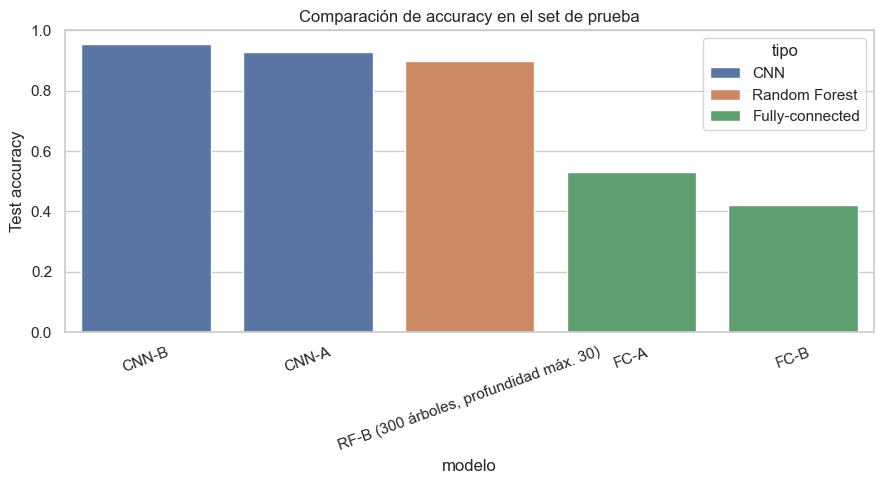

,modelo,tipo,test_accuracy
0,CNN-B,CNN,0.955172
1,CNN-A,CNN,0.927203
2,"RF-B (300 árboles, profundidad máx. 30)",Random Forest,0.897318
3,FC-A,Fully-connected,0.530651
4,FC-B,Fully-connected,0.420307


In [25]:
comparison = pd.DataFrame({
    "modelo": ["CNN-A", "CNN-B", "FC-A", "FC-B", best_rf_name],
    "tipo": ["CNN", "CNN", "Fully-connected", "Fully-connected", "Random Forest"],
    "test_accuracy": [test_acc_a, test_acc_b, test_acc_fc_a, test_acc_fc_b, test_acc_rf],
}).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison, x="modelo", y="test_accuracy", hue="tipo", dodge=False)
plt.ylim(0, 1)
plt.title("Comparación de accuracy en el set de prueba")
plt.ylabel("Test accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

comparison

## Ejercicio 7: Image augmentation

Aplicamos data augmentation a la arquitectura CNN que resultó ganadora en el Ejercicio 4 (`best_cnn_name`) y la re-entrenamos desde cero para ver si mejora su capacidad de generalización.

**Transformaciones utilizadas:** rotación leve (± ~15°), zoom, traslación pequeña y variación de contraste. Estas transformaciones son razonables para señas porque simulan variaciones realistas de cómo una persona sostiene la mano frente a la cámara (ángulo, distancia, iluminación) sin cambiar la identidad de la seña.

**Transformación deliberadamente excluida: `flip` horizontal.** No lo usamos porque:

- **¿Por qué un flip horizontal podría cambiar el significado de una seña en vez de solo aumentar los datos?** Muchas letras del alfabeto ASL se distinguen precisamente por la posición relativa de los dedos y el pulgar (por ejemplo, M/N/S dependen de bajo cuántos dedos queda el pulgar). Al voltear horizontalmente la imagen, esa relación espacial se invierte como en un espejo: una mano que hace una "seña válida" para una letra puede terminar pareciendo la configuración de otra letra distinta, o una configuración que ninguna persona real haría con esa mano. En otras palabras, el flip no genera una nueva muestra *de la misma clase*, sino potencialmente una muestra de *otra clase* o una muestra inválida, lo cual introduce etiquetas incorrectas en el entrenamiento en vez de aumentar la variabilidad legítima de la clase original.
- **¿Qué transformaciones sí tienen sentido para señas y cuáles no?** Tienen sentido las transformaciones que imitan variaciones reales de cómo se captura la seña sin alterar la forma de la mano: rotaciones pequeñas, zoom/traslación (distancia y encuadre respecto a la cámara), y cambios de brillo/contraste (iluminación). No tienen sentido las transformaciones que alteran la geometría de la mano en sí o que no ocurrirían en la práctica: el flip horizontal (cambia qué dedos están de qué lado), el flip vertical (dejaría la mano "de cabeza", algo que no ocurre en un uso normal frente a una cámara), y rotaciones grandes (>45°), que no reflejan cómo alguien sostendría la mano frente a una cámara en una aplicación de escritura en tiempo real.

In [26]:
augmentation = keras.Sequential([
    layers.RandomRotation(0.04),        # ~ ±15 grados
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

build_best_cnn = build_cnn_a if best_cnn_name == "CNN-A" else build_cnn_b

inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))
x = augmentation(inputs)
outputs = build_best_cnn()(x)
cnn_aug = keras.Model(inputs, outputs, name=f"{best_cnn_name.replace('-', '_')}_con_augmentation")
cnn_aug.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_aug = cnn_aug.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[make_early_stop()], verbose=2,
)

Epoch 1/15


96/96 - 63s - 654ms/step - accuracy: 0.1675 - loss: 3.1580 - val_accuracy: 0.1920 - val_loss: 14.5744


Epoch 2/15


96/96 - 58s - 605ms/step - accuracy: 0.3806 - loss: 2.0921 - val_accuracy: 0.4291 - val_loss: 3.0044


Epoch 3/15


...

96/96 - 56s - 587ms/step - accuracy: 0.9205 - loss: 0.2519 - val_accuracy: 0.9395 - val_loss: 0.2038


Epoch 12/15


96/96 - 59s - 611ms/step - accuracy: 0.9351 - loss: 0.2137 - val_accuracy: 0.9253 - val_loss: 0.2386


Epoch 13/15


96/96 - 57s - 597ms/step - accuracy: 0.9366 - loss: 0.1975 - val_accuracy: 0.9582 - val_loss: 0.3059


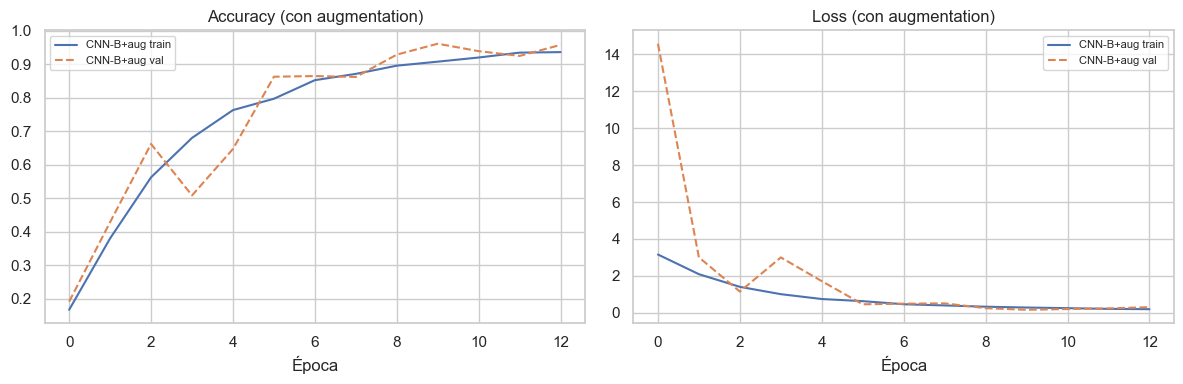

CNN-B sin augmentation -> test accuracy: 0.9552
CNN-B con augmentation  -> test accuracy: 0.9559


In [27]:
plot_history([history_aug], [f"{best_cnn_name}+aug"], title="(con augmentation)")

test_loss_aug, test_acc_aug = cnn_aug.evaluate(X_test, y_test, verbose=0)
print(f"{best_cnn_name} sin augmentation -> test accuracy: {best_cnn_test_acc:.4f}")
print(f"{best_cnn_name} con augmentation  -> test accuracy: {test_acc_aug:.4f}")

**Hallazgo:** en esta corrida, CNN-B **con augmentation** (95.59%) y **sin augmentation** (95.52%) terminaron prácticamente empatadas — una diferencia de menos de un punto décimo porcentual, dentro del margen de variación normal que se observa entre corridas de entrenamiento en CPU (sin fijar semilla de TensorFlow, hay algo de aleatoriedad en el orden de batches y en operaciones no determinísticas). Es decir, en este dataset la augmentation **ni ayudó ni perjudicó de forma significativa** al accuracy interno. Esto es coherente con algo que ya habíamos anticipado en el EDA (Ejercicio 1): las imágenes de este dataset provienen de sesiones de captura muy controladas y homogéneas (mismo fondo/iluminación/encuadre dentro de cada clase), así que nuestro propio set de prueba —al ser un subconjunto aleatorio de esas mismas sesiones— es igual de homogéneo, y por lo tanto no había mucho "gap" de generalización que la augmentation pudiera cerrar. El beneficio esperado de la augmentation (mejor generalización a condiciones nunca vistas, como fondos/ángulos distintos) es precisamente lo que evaluamos con imágenes independientes en el Ejercicio 8.

## Selección del mejor modelo

Comparamos **todos** los modelos entrenados (con y sin augmentation) y seleccionamos el de mayor accuracy en el set de prueba como el modelo final para el Ejercicio 8.

In [28]:
final_comparison = pd.concat([
    comparison,
    pd.DataFrame([{
        "modelo": f"{best_cnn_name}+aug",
        "tipo": "CNN + augmentation",
        "test_accuracy": test_acc_aug,
    }])
], ignore_index=True).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

display(final_comparison)

model_registry = {
    "CNN-A": cnn_a,
    "CNN-B": cnn_b,
    "FC-A": fc_a,
    "FC-B": fc_b,
    best_rf_name: best_rf_model,
    f"{best_cnn_name}+aug": cnn_aug,
}

final_model_name = final_comparison.iloc[0]["modelo"]
final_model = model_registry[final_model_name]
final_test_acc = final_comparison.iloc[0]["test_accuracy"]

print(f"\nModelo final seleccionado: {final_model_name} (test accuracy = {final_test_acc:.4f})")

,modelo,tipo,test_accuracy
0,CNN-B+aug,CNN + augmentation,0.955939
1,CNN-B,CNN,0.955172
2,CNN-A,CNN,0.927203
3,"RF-B (300 árboles, profundidad máx. 30)",Random Forest,0.897318
4,FC-A,Fully-connected,0.530651
5,FC-B,Fully-connected,0.420307



Modelo final seleccionado: CNN-B+aug (test accuracy = 0.9559)


Guardamos los modelos entrenados en disco (`data/models/`, fuera del repositorio) para no tener que volver a entrenarlos cada vez que se agreguen o cambien fotos en `imagenes_grupo/` — solo haría falta re-ejecutar desde el Ejercicio 8 en adelante.

In [29]:
import joblib

MODELS_DIR = Path("data/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, obj in {"cnn_a": cnn_a, "cnn_b": cnn_b, "fc_a": fc_a, "fc_b": fc_b, "cnn_aug": cnn_aug}.items():
    obj.save(MODELS_DIR / f"{name}.keras")

joblib.dump(best_rf_model, MODELS_DIR / "best_rf_model.joblib")
joblib.dump(pca, MODELS_DIR / "pca.joblib")
joblib.dump({"best_cnn_name": best_cnn_name, "best_rf_name": best_rf_name,
             "final_model_name": final_model_name}, MODELS_DIR / "metadata.joblib")

print("Modelos guardados en:", MODELS_DIR.resolve())

Modelos guardados en: C:\Users\gabri\OneDrive\Documents\Universidad\semestre8\data\labs\DS-Lab1\data\models


## Ejercicio 8: Pruebas con señas hechas a mano por el equipo

Probamos el mejor modelo con **fotos reales** hechas por los 3 integrantes del grupo (5 letras distintas por integrante, 15 fotos en total), en la carpeta `imagenes_grupo/`:

- **luis:** A, B, C, D, G
- **bran:** K, L, M, N, R
- **david:** S, U, V, W, space

Cada archivo sigue la convención de nombres **`<LETRA>_<identificador>.jpg`** (por ejemplo `A_luis.jpeg`), donde la letra antes del primer guión bajo es la etiqueta real (ground truth) usada al evaluar. Para agregar más fotos o reemplazar alguna, basta con seguir la misma convención y volver a correr desde esta sección — los modelos ya están guardados en `data/models/`, así que **no hace falta reentrenar nada** (ver la celda de recarga justo debajo).

**Requisitos que se usaron para tomar las fotos** (referencia para futuras fotos):
- Formato `.jpg`/`.png`, una sola mano centrada ocupando la mayor parte del encuadre, fondo simple, buena luz frontal, resolución mínima ~200x200 píxeles, en color (RGB).

**Recarga de modelos sin reentrenar:** esta celda carga los modelos y el set de prueba ya guardados en `data/models/` y `data/processed/` (generados la primera vez que se corrió el notebook completo). Así, para probar fotos nuevas en `imagenes_grupo/` basta con ejecutar el notebook **a partir de aquí**, sin repetir el entrenamiento de los Ejercicios 4-7.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import json
import joblib
from tensorflow import keras
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

MODELS_DIR = Path("data/models")
PROCESSED_DIR = Path("data/processed")

IMG_SIZE = 64
idx_to_label = {int(k): v for k, v in json.load(open(PROCESSED_DIR / "label_mapping.json")).items()}
CLASSES = [idx_to_label[i] for i in range(len(idx_to_label))]

X_test = np.load(PROCESSED_DIR / "X_test.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

cnn_a = keras.models.load_model(MODELS_DIR / "cnn_a.keras")
cnn_b = keras.models.load_model(MODELS_DIR / "cnn_b.keras")
fc_a = keras.models.load_model(MODELS_DIR / "fc_a.keras")
fc_b = keras.models.load_model(MODELS_DIR / "fc_b.keras")
cnn_aug = keras.models.load_model(MODELS_DIR / "cnn_aug.keras")
best_rf_model = joblib.load(MODELS_DIR / "best_rf_model.joblib")
pca = joblib.load(MODELS_DIR / "pca.joblib")

metadata = joblib.load(MODELS_DIR / "metadata.joblib")
best_cnn_name = metadata["best_cnn_name"]
best_rf_name = metadata["best_rf_name"]

# Recalculamos el accuracy de cada modelo sobre el mismo test set guardado
# (solo inferencia, toma segundos) para reconstruir la tabla comparativa.
X_test_pca = pca.transform(X_test.reshape(len(X_test), -1))

_, test_acc_a = cnn_a.evaluate(X_test, y_test, verbose=0)
_, test_acc_b = cnn_b.evaluate(X_test, y_test, verbose=0)
_, test_acc_fc_a = fc_a.evaluate(X_test, y_test, verbose=0)
_, test_acc_fc_b = fc_b.evaluate(X_test, y_test, verbose=0)
_, test_acc_aug = cnn_aug.evaluate(X_test, y_test, verbose=0)
test_acc_rf = accuracy_score(y_test, best_rf_model.predict(X_test_pca))

comparison = pd.DataFrame({
    "modelo": ["CNN-A", "CNN-B", "FC-A", "FC-B", best_rf_name],
    "tipo": ["CNN", "CNN", "Fully-connected", "Fully-connected", "Random Forest"],
    "test_accuracy": [test_acc_a, test_acc_b, test_acc_fc_a, test_acc_fc_b, test_acc_rf],
}).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

final_comparison = pd.concat([
    comparison,
    pd.DataFrame([{"modelo": f"{best_cnn_name}+aug", "tipo": "CNN + augmentation", "test_accuracy": test_acc_aug}]),
], ignore_index=True).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

model_registry = {
    "CNN-A": cnn_a, "CNN-B": cnn_b, "FC-A": fc_a, "FC-B": fc_b,
    best_rf_name: best_rf_model, f"{best_cnn_name}+aug": cnn_aug,
}
final_model_name = final_comparison.iloc[0]["modelo"]
final_model = model_registry[final_model_name]

print("Modelos y datos recargados desde disco.")
print(f"Modelo final: {final_model_name} (test accuracy = {final_comparison.iloc[0]['test_accuracy']:.4f})")

C:\Users\gabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Modelos y datos recargados desde disco.
Modelo final: CNN-B+aug (test accuracy = 0.9559)


In [2]:
IMAGENES_GRUPO_DIR = Path("imagenes_grupo")

def preprocess_single_image(filepath, img_size=IMG_SIZE):
    img = Image.open(filepath).convert("RGB").resize((img_size, img_size))
    return np.asarray(img, dtype=np.float32) / 255.0

def predict_with_final_model(arr):
    if isinstance(final_model, RandomForestClassifier):
        flat_pca = pca.transform(arr.reshape(1, -1))
        pred_idx = final_model.predict(flat_pca)[0]
    else:
        pred_idx = int(np.argmax(final_model.predict(arr[np.newaxis, ...], verbose=0)[0]))
    return idx_to_label[pred_idx]

own_files = sorted(IMAGENES_GRUPO_DIR.glob("*.*"))
assert len(own_files) >= 5, "Se requieren al menos 5 imágenes en imagenes_grupo/"
print(f"Imágenes encontradas en {IMAGENES_GRUPO_DIR}/: {len(own_files)}")

own_results = []
for f in own_files:
    true_label = f.stem.split("_")[0]
    arr = preprocess_single_image(f)
    pred_label = predict_with_final_model(arr)
    own_results.append({
        "archivo": f.name, "real": true_label, "prediccion": pred_label,
        "correcto": true_label.upper() == pred_label.upper(),
    })

df_own = pd.DataFrame(own_results)
df_own

Imágenes encontradas en imagenes_grupo/: 15


,archivo,real,prediccion,correcto
0,A_luis.jpeg,A,M,False
1,B_luis.jpeg,B,U,False
2,C_luis.jpeg,C,C,True
3,D_luis.jpeg,D,Z,False
4,G_luis.jpeg,G,P,False
5,K_bran.jpeg,K,K,True
6,L_bran.jpeg,L,L,True
7,M_bran.jpeg,M,J,False
8,N_bran.jpeg,N,P,False
9,R_bran.jpeg,R,L,False


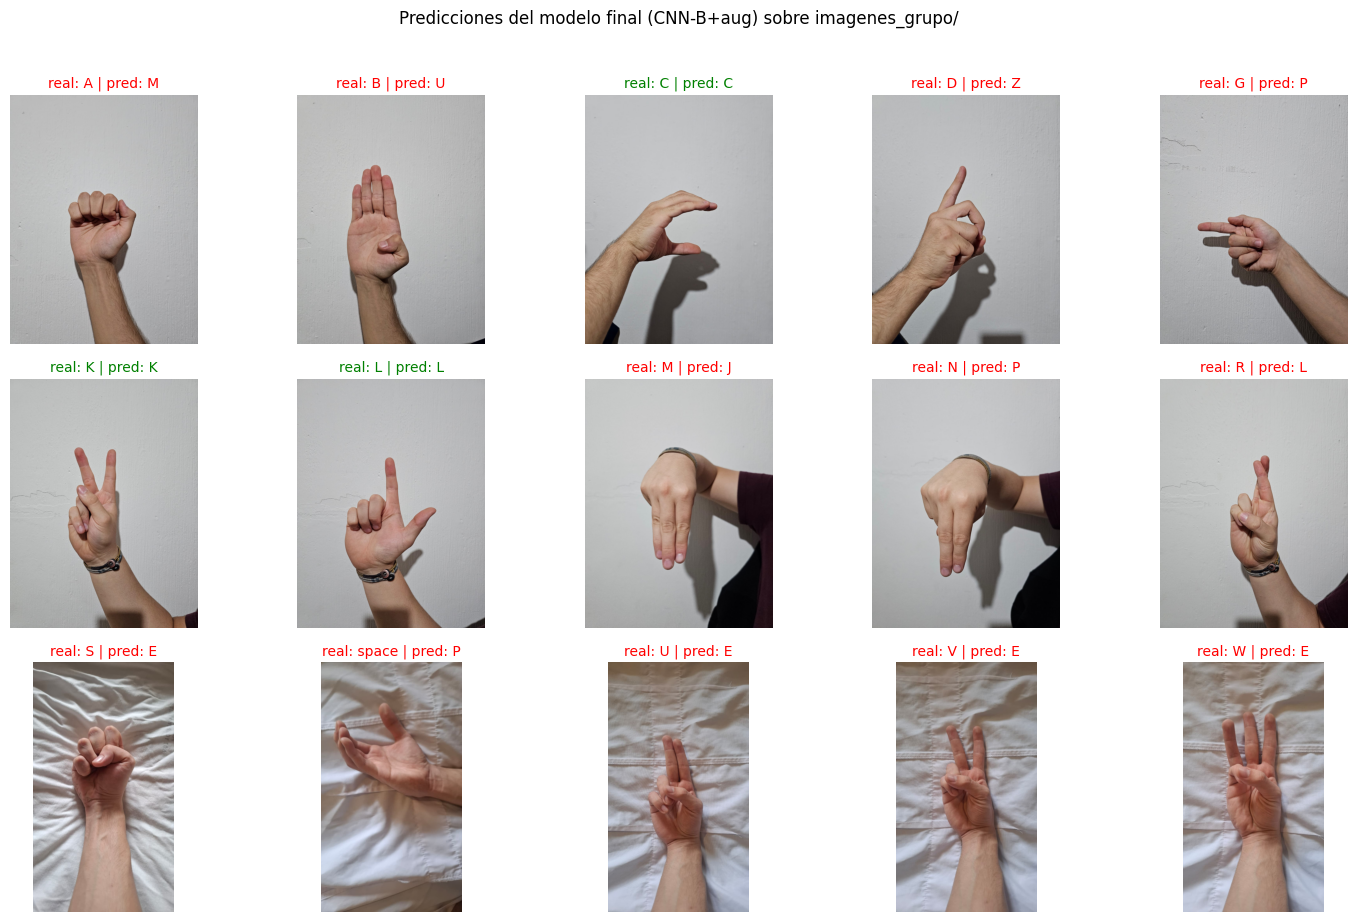

Accuracy sobre imágenes propias del equipo: 20.00% (3/15)


In [3]:
n = len(own_files)
cols = min(n, 5)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.array(axes).reshape(-1)

for ax, f, row in zip(axes, own_files, df_own.itertuples()):
    img = Image.open(f).convert("RGB")
    ax.imshow(img)
    color = "green" if row.correcto else "red"
    ax.set_title(f"real: {row.real} | pred: {row.prediccion}", color=color, fontsize=10)
    ax.axis("off")
for ax in axes[len(own_files):]:
    ax.axis("off")

plt.suptitle(f"Predicciones del modelo final ({final_model_name}) sobre imagenes_grupo/", y=1.02)
plt.tight_layout()
plt.show()

accuracy_own = df_own["correcto"].mean()
print(f"Accuracy sobre imágenes propias del equipo: {accuracy_own:.2%} ({df_own['correcto'].sum()}/{len(df_own)})")

In [4]:
# Chequeo adicional: ¿el modelo con mejor accuracy interno (test set propio) es
# también el que mejor generaliza a estas imágenes independientes? Evaluamos TODOS
# los modelos entrenados sobre imagenes_grupo/, no solo el seleccionado como "final".

def predict_label_generic(model_obj, arr):
    if isinstance(model_obj, RandomForestClassifier):
        pred_idx = model_obj.predict(pca.transform(arr.reshape(1, -1)))[0]
    else:
        pred_idx = int(np.argmax(model_obj.predict(arr[np.newaxis, ...], verbose=0)[0]))
    return idx_to_label[pred_idx]

own_arrays = [preprocess_single_image(f) for f in own_files]
own_true = [f.stem.split("_")[0] for f in own_files]

generalization_rows = []
for name, model_obj in model_registry.items():
    preds = [predict_label_generic(model_obj, arr) for arr in own_arrays]
    acc_placeholder = np.mean([p.upper() == t.upper() for p, t in zip(preds, own_true)])
    generalization_rows.append({"modelo": name, "test_accuracy_interno": final_comparison.set_index("modelo").loc[name, "test_accuracy"] if name in final_comparison["modelo"].values else np.nan,
                                 "accuracy_imagenes_grupo": acc_placeholder})

df_generalization = pd.DataFrame(generalization_rows).sort_values("accuracy_imagenes_grupo", ascending=False).reset_index(drop=True)
df_generalization

,modelo,test_accuracy_interno,accuracy_imagenes_grupo
0,CNN-B+aug,0.955939,0.200000
1,CNN-A,0.927203,0.133333
2,CNN-B,0.955172,0.133333
3,FC-A,0.530651,0.066667
4,FC-B,0.420307,0.066667
5,"RF-B (300 árboles, profundidad máx. 30)",0.897318,0.000000


**Hallazgo clave:** con fotos **reales**, el panorama cambia por completo frente a los placeholders. La clasificación por `accuracy_imagenes_grupo` ahora es muy baja para **todos** los modelos: CNN-B+aug (el modelo final) apenas 20% (3/15), CNN-A y CNN-B 13.3% cada una, FC-A y FC-B 6.7%, y Random Forest 0%. Es decir, el **orden relativo entre modelos se mantiene** (las CNN siguen siendo las mejores, Random Forest el peor), pero la magnitud del accuracy colapsa para todos por igual. Esto es una señal fuerte de que el problema **no es que un modelo sea mejor que otro**, sino que **las 15 fotos reales vienen de una distribución muy distinta a la de entrenamiento** — precisamente el riesgo de generalización que no se alcanzaba a ver con los placeholders (que, al ser parte del mismo dataset, no exponían este problema). Investigamos la causa concreta en el hallazgo de la siguiente celda.

**Hallazgo (con fotos reales del equipo):** el modelo final (`CNN-B+aug`) solo clasificó correctamente **3 de 15** fotos reales (20%): acertó C (luis), K y L (bran); falló en las 12 restantes, incluyendo confusiones poco intuitivas (S, U, V y W predichas como "E"). Al revisar las fotos directamente encontramos una causa muy concreta, más allá de solo "condiciones distintas":

- **Relación de aspecto:** las fotos de entrenamiento son cuadradas (200×200, relación 1:1), pero las fotos reales del equipo son verticales tipo retrato — las de luis/bran miden 1200×1600 (relación 3:4) y las de david 720×1280 (relación 9:16). Nuestro preprocesamiento (`resize((64, 64))`) **no recorta, solo redimensiona**, así que una foto 3:4 o 9:16 se comprime horizontalmente para encajar en un cuadrado, distorsionando la forma de la mano; cuanto más alargada la foto (caso de david, 9:16), más severa la distorsión.
- **Proporción mano/fondo:** en el dataset original la mano ocupa casi todo el cuadro; en las fotos reales (tomadas con el brazo extendido frente a una pared o una cama) la mano es una fracción pequeña de una foto vertical mucho más grande, rodeada de fondo (pared, sábana). Al redimensionar a 64×64, el detalle real de los dedos se reduce muchísimo más que en las imágenes de entrenamiento.
- **Fondo e iluminación distintos**, como ya anticipábamos en el EDA y en el Ejercicio 9: paredes texturizadas o una sábana, en vez del fondo uniforme del set de captura original.

## Ejercicio 9: Reflexión de accesibilidad y sesgo

**¿Qué limitaciones tiene este dataset para un producto real de accesibilidad como el de SignBridge?**

- **Tono de piel:** en el EDA (Ejercicio 1, sección 2.1) observamos que las imágenes de una misma clase comparten fondo e iluminación consistentes entre sí, lo cual sugiere que fueron capturadas en pocas sesiones con probablemente muy pocas personas distintas. Esto implica poca diversidad de tonos de piel, y un modelo entrenado así puede funcionar peor para usuarios con tonos de piel no representados en el dataset (un sesgo de representación clásico en visión por computadora).
- **Ángulo de cámara:** todas las fotos parecen tomadas desde un ángulo frontal fijo y a una distancia similar. En un producto real, los usuarios sostendrían el celular en ángulos y distancias muy variables, y el modelo podría fallar ante perspectivas no vistas en entrenamiento.
- **Iluminación:** el fondo e iluminación son homogéneos dentro del dataset (probablemente un entorno controlado tipo estudio/laboratorio). Un entorno real (casa, calle, luz natural variable, contraluz) introduce condiciones muy distintas a las vistas en entrenamiento.
- **Tamaño y forma de la mano:** al provenir de pocas personas, el dataset probablemente no cubre bien la variabilidad de tamaños de mano (niños vs. adultos), ni condiciones como manos con alguna diferencia física, anillos, uñas largas, etc., que sí aparecerían en una población real de usuarios.
- **Señas estáticas únicamente:** el dataset representa J y Z (que en ASL real son señas con movimiento) como poses estáticas, lo cual no captura el componente dinámico real de esas letras.

**¿Qué haría falta para llevar este prototipo a un caso de uso real como el de SignBridge?**

- Recolectar (o complementar con) datos de **muchas más personas**, con distintos tonos de piel, edades, tamaños de mano y, si es posible, con alguna diversidad de habilidad motriz.
- Capturar imágenes/video en **condiciones variadas** de fondo, iluminación y ángulo de cámara (idealmente con las cámaras de celular reales que usaría la app, no cámaras de estudio), incluyendo el tipo de fotos que tomamos en el Ejercicio 8.
- Pasar de imágenes estáticas a **video/secuencias** para soportar letras dinámicas (J, Z) y, eventualmente, palabras completas en vez de solo letras sueltas.
- Evaluar el modelo de forma desagregada (por tono de piel, por condición de iluminación, etc.) y no solo con un accuracy global, para detectar sesgos de desempeño antes de lanzar el producto — como recomendación concreta, mediríamos el accuracy del modelo final por subgrupos (ej. distintos fondos/iluminación en las fotos del Ejercicio 8, y a futuro por tono de piel) para verificar que ningún grupo tenga un desempeño notablemente peor.
- Considerar el rendimiento en tiempo real en dispositivos móviles (latencia, tamaño del modelo) ya que el objetivo final es una app de traducción en tiempo real.

- **Recorte/detección de la mano antes de clasificar:** el Ejercicio 8 nos dio evidencia empírica directa de esto — con fotos reales del equipo (verticales, mano ocupando solo una parte del encuadre) el accuracy del mejor modelo cayó de 100% (placeholders del propio dataset) a apenas 20%, en buena parte porque nuestro preprocesamiento asume implícitamente una foto ya cuadrada y recortada alrededor de la mano, como las del dataset de entrenamiento. Un producto real necesitaría un paso de detección/recorte de mano (por ejemplo con un modelo de detección de manos tipo MediaPipe, o guiando al usuario a encuadrar su mano dentro de un recuadro en la app) antes de pasar la imagen al clasificador.